Importing libraries

In [325]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

Loading data with K

In [326]:
df = pd.read_csv("station07_with_K_ratios.csv")

print(df.shape)
print(df.head())

(15244, 25)
   Unnamed: 0                  date_time  nwp_globalirrad  nwp_directirrad  \
0          25  2018-06-30 22:15:00+00:00           138.17           111.91   
1          26  2018-06-30 22:30:00+00:00           173.06           144.17   
2          27  2018-06-30 22:45:00+00:00           226.87           194.66   
3          28  2018-06-30 23:00:00+00:00           263.36           229.25   
4          29  2018-06-30 23:15:00+00:00           318.42           281.82   

   nwp_temperature  nwp_humidity  nwp_windspeed  nwp_winddirection  \
0            20.67         50.14           2.51             357.79   
1            21.42         49.07           2.20             359.45   
2            22.39         47.59           1.71               2.01   
3            23.19         44.78           1.16               4.73   
4            23.93         42.80           0.79              30.53   

   nwp_pressure  lmd_totalirrad  ...     power   GHI_clear   DNI_clear  \
0        930.40         

In [327]:
print(df.columns.tolist())

['Unnamed: 0', 'date_time', 'nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity', 'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'lmd_totalirrad', 'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure', 'lmd_winddirection', 'lmd_windspeed', 'power', 'GHI_clear', 'DNI_clear', 'DHI_clear', 'POA_clear', 'P_theoretical_W', 'power_W', 'GHI_ratio', 'DNI_ratio', 'K_PV']


In [328]:
print(df.columns.tolist())

['Unnamed: 0', 'date_time', 'nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity', 'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'lmd_totalirrad', 'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure', 'lmd_winddirection', 'lmd_windspeed', 'power', 'GHI_clear', 'DNI_clear', 'DHI_clear', 'POA_clear', 'P_theoretical_W', 'power_W', 'GHI_ratio', 'DNI_ratio', 'K_PV']


I will choose the features

In [329]:
features = [
    "nwp_globalirrad",
    "nwp_directirrad",
    "nwp_temperature",
    "nwp_humidity",
    "nwp_windspeed",
    "nwp_winddirection",
    "nwp_pressure",
    "GHI_ratio",
    "DNI_ratio",
]
target = "K_PV"

Creating ML dataset

In [330]:
ml_data = df[features + [target]].dropna()

print("Training rows:", len(ml_data))
print(ml_data.head())

Training rows: 13182
   nwp_globalirrad  nwp_directirrad  nwp_temperature  nwp_humidity  \
4           318.42           281.82            23.93         42.80   
5           355.06           316.98            24.52         40.86   
6           409.48           369.42            25.11         39.86   
7           445.24           403.99            25.66         38.08   
8           497.82           454.93            26.13         36.60   

   nwp_windspeed  nwp_winddirection  nwp_pressure  GHI_ratio  DNI_ratio  \
4           0.79              30.53        930.82   1.074462   0.493681   
5           0.67              67.50        930.80   1.019038   0.516732   
6           0.76             110.43        930.74   1.023125   0.568828   
7           1.00             120.39        930.76   0.987410   0.595298   
8           1.30             114.90        930.84   0.993678   0.645346   

       K_PV  
4  0.696086  
5  0.703638  
6  0.705122  
7  0.703488  
8  0.717405  


In [331]:
X = ml_data[features]
y = ml_data[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (13182, 9)
y shape: (13182,)


Splitting data

In [332]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (10545, 9)
Testing: (2637, 9)


Training the model

In [333]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [334]:
y_pred = model.predict(X_test)

Evaluating

In [335]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.07605796995884218
RMSE: 0.10695231913566747
R²: 0.7834642235586126


Comparing

In [336]:
comparison = pd.DataFrame({
    "Actual_K": y_test.values,
    "Predicted_K": y_pred
})

print(comparison.head(20))

    Actual_K  Predicted_K
0   0.642635     0.553719
1   0.304711     0.338655
2   0.749630     0.654721
3   0.317242     0.240414
4   0.235582     0.177549
5   0.564298     0.474475
6   0.500915     0.639928
7   0.573461     0.559957
8   0.420459     0.432613
9   0.000000     0.001180
10  0.494489     0.498535
11  0.344738     0.438220
12  0.112189     0.109392
13  0.449490     0.445129
14  0.207750     0.241252
15  0.471531     0.505882
16  0.022310     0.037337
17  0.354497     0.349755
18  0.455917     0.458028
19  0.096182     0.214396


In [337]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(importance)

             Feature  Importance
8          DNI_ratio    0.462483
2    nwp_temperature    0.103186
7          GHI_ratio    0.088349
6       nwp_pressure    0.084187
3       nwp_humidity    0.078756
5  nwp_winddirection    0.069996
4      nwp_windspeed    0.063379
0    nwp_globalirrad    0.029031
1    nwp_directirrad    0.020633


The below cell was inserted later to the notebook

In [338]:
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Load Data
df = pd.read_csv("station07_with_K_ratios.csv")

# 2. Select Features & Target
features = [
    "nwp_globalirrad",
    "nwp_directirrad",
    "nwp_temperature",
    "nwp_humidity",
    "nwp_windspeed",
    "nwp_winddirection",
    "nwp_pressure",
    "GHI_ratio",
    "DNI_ratio",
]
target = "K_PV"

ml_data = df[features + [target]].dropna()

X = ml_data[features]
y = ml_data[target]

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Initialize & Train Random Forest
model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

model.fit(X_train, y_train)

# 5. Evaluate Performance
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


joblib.dump(model, "random_forest_k_pv.pkl")
print("Model successfully saved as 'random_forest_k_pv.pkl'!")

MAE:  0.0761
RMSE: 0.1070
R²:   0.7835
Model successfully saved as 'random_forest_k_pv.pkl'!


Training on 2018, and testing on 2019 (i taught this is a good idea but it seemed it is not)

In [339]:
df["date_time"] = pd.to_datetime(df["date_time"])

train_data = df[
    (df["date_time"].dt.year == 2018) &
    (df["K_PV"].notna())
]

test_data = df[
    (df["date_time"].dt.year == 2019) &
    (df["K_PV"].notna())
]

In [340]:
X_train = train_data[features]
y_train = train_data["K_PV"]

X_test = test_data[features]
y_test = test_data["K_PV"]

In [341]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [342]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.14380942589279266
RMSE: 0.18212323025516475
R²: 0.4607896637175861


Ohhhhhh... But maybe the system performance has varied between 2018 and 2019:

In [343]:
print("2018 rows:", len(train_data))
print("2019 rows:", len(test_data))

print("\n2018 K:")
print(y_train.describe())

print("\n2019 K:")
print(y_test.describe())

2018 rows: 6990
2019 rows: 6192

2018 K:
count    6990.000000
mean        0.413242
std         0.213726
min         0.000000
25%         0.220242
50%         0.467569
75%         0.601111
max         1.036025
Name: K_PV, dtype: float64

2019 K:
count    6192.000000
mean        0.478260
std         0.248040
min         0.000000
25%         0.263462
50%         0.511844
75%         0.703056
max         0.992243
Name: K_PV, dtype: float64


In [344]:
print("\n2018 feature means:")
print(X_train.mean())

print("\n2019 feature means:")
print(X_test.mean())


2018 feature means:
nwp_globalirrad      325.035292
nwp_directirrad      283.912443
nwp_temperature       17.920787
nwp_humidity          44.516263
nwp_windspeed          4.127416
nwp_winddirection    167.826946
nwp_pressure         939.347843
GHI_ratio              0.639251
DNI_ratio              0.341721
dtype: float64

2019 feature means:
nwp_globalirrad      452.875891
nwp_directirrad      400.532234
nwp_temperature       13.735260
nwp_humidity          29.923448
nwp_windspeed          4.933046
nwp_winddirection    176.824328
nwp_pressure         939.403327
GHI_ratio              0.781361
DNI_ratio              0.465413
dtype: float64


In [345]:
print("\n2018 K median:", y_train.median())
print("2019 K median:", y_test.median())

print("2018 K mean:", y_train.mean())
print("2019 K mean:", y_test.mean())


2018 K median: 0.4675691688689621
2019 K median: 0.5118435089956499
2018 K mean: 0.41324226819160187
2019 K mean: 0.4782596275492692


In [346]:
df["date_time"] = pd.to_datetime(df["date_time"])

df["year"] = df["date_time"].dt.year

print(
    df.groupby("year")["K_PV"].describe()
)

       count      mean       std  min       25%       50%       75%       max
year                                                                         
2018  6990.0  0.413242  0.213726  0.0  0.220242  0.467569  0.601111  1.036025
2019  6192.0  0.478260  0.248040  0.0  0.263462  0.511844  0.703056  0.992243


In [347]:
print(
    df.groupby("year")["P_theoretical_W"].describe()
)

       count          mean           std            min           25%  \
year                                                                    
2018  8111.0  1.223813e+07  6.008688e+06  503022.653583  7.126302e+06   
2019  7133.0  1.259219e+07  6.158268e+06  500369.653863  7.549183e+06   

               50%           75%         max  
year                                          
2018  1.355522e+07  1.776586e+07  20000000.0  
2019  1.404457e+07  1.823088e+07  20000000.0  


In [348]:
print(
    df.groupby("year")["power_W"].describe()
)

       count          mean           std  min        25%        50%  \
year                                                                  
2018  8111.0  5.196240e+06  4.016433e+06  0.0  1477944.0  4376988.0   
2019  7133.0  6.165608e+06  4.735108e+06  0.0  1804797.0  5243859.0   

             75%         max  
year                          
2018   8782398.0  15177350.0  
2019  10132440.0  17280581.0  


In [349]:
daytime = df[
    (df["P_theoretical_W"] > 1_000_000) &
    (df["K_PV"].notna())
]

print("Rows:", len(daytime))
print(daytime["K_PV"].describe())

Rows: 13182
count    13182.000000
mean         0.443783
std          0.232746
min          0.000000
25%          0.241033
50%          0.487356
75%          0.633734
max          1.036025
Name: K_PV, dtype: float64


Conclusion: I did a research about the city seasons. It was not loggical to train on high temperature of summer with mid temperature of automn and test in low temperatures of winter and mid of spring

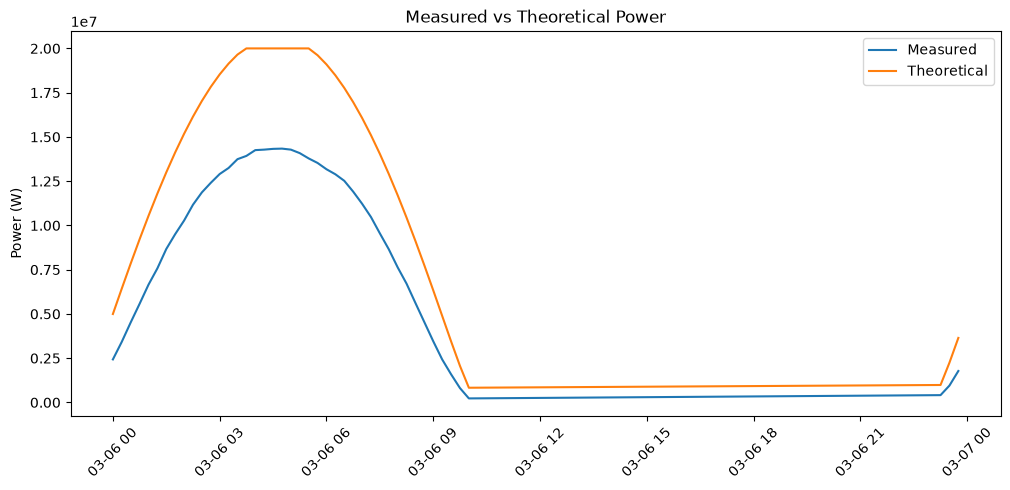

In [350]:
import matplotlib.pyplot as plt

day = df[
    df["date_time"].dt.date == pd.Timestamp("2019-03-06").date()
].copy()

plt.figure(figsize=(12, 5))

plt.plot(
    day["date_time"],
    day["power_W"],
    label="Measured"
)

plt.plot(
    day["date_time"],
    day["P_theoretical_W"],
    label="Theoretical"
)

plt.legend()
plt.xticks(rotation=45)
plt.ylabel("Power (W)")
plt.title("Measured vs Theoretical Power")
plt.show()

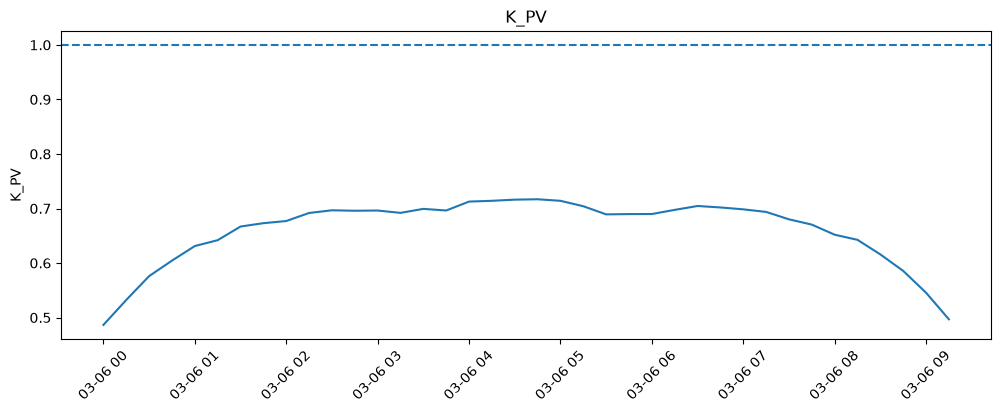

In [351]:
plt.figure(figsize=(12, 4))

plt.plot(
    day["date_time"],
    day["K_PV"]
)

plt.axhline(1, linestyle="--")

plt.ylabel("K_PV")
plt.title("K_PV")
plt.xticks(rotation=45)

plt.show()

I tried another model and added more features to handle seasonal and hourly changes. However i decided to use the previous model with higher accuracy

In [352]:
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split


df = pd.read_csv("station07_with_K_ratios.csv")
df_valid = df.dropna(subset=["K_PV"]).copy()
df_valid["date_time"] = pd.to_datetime(df_valid["date_time"])
df_valid = df_valid.set_index("date_time")

# Add seasonal & daily cyclical features
df_valid["hour_sin"] = np.sin(2 * np.pi * df_valid.index.hour / 24.0)
df_valid["hour_cos"] = np.cos(2 * np.pi * df_valid.index.hour / 24.0)
df_valid["month_sin"] = np.sin(2 * np.pi * df_valid.index.month / 12.0)
df_valid["month_cos"] = np.cos(2 * np.pi * df_valid.index.month / 12.0)

feature_cols = [
    "POA_clear",
    "GHI_clear",
    "DNI_clear",
    "DHI_clear",
    "GHI_ratio",
    "DNI_ratio",
    "nwp_temperature",
    "nwp_humidity",
    "nwp_windspeed",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
]

X = df_valid[feature_cols]
y = df_valid["K_PV"]

# Perform 80/20 Train-Test Split across all months
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = HistGradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)


preds = model.predict(X_test)
print(f"80/20 Split R² Score: {r2_score(y_test, preds):.4f}")
print(f"80/20 Split MAE:      {mean_absolute_error(y_test, preds):.4f}")


joblib.dump(model, "solar_loss_model.pkl")
print("Saved model as 'solar_loss_model.pkl'")

80/20 Split R² Score: 0.6998
80/20 Split MAE:      0.0928
Saved model as 'solar_loss_model.pkl'
